# I. Data preparation

## Download ImageNetMini dataset

In [49]:
# See if torchmetrics exists, if not, install it
try:
    import kagglehub
    print(f"hagglehub version: {kagglehub.__version__}")
except:
    %pip install kagglehub
    import kagglehub
    print(f"kagglehub version: {kagglehub.__version__}")

hagglehub version: 1.0.1


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [50]:
import os
import shutil

# Download latest version of ImageNetMini. 
downloaded_path = kagglehub.dataset_download("deeptrial/miniimagenet")
print("Path to downloaded dataset files:", downloaded_path)

# Create miniimagenet directory
current_path = os.getcwd().split("\\")
parent_path = '\\'.join(current_path[:-1])
miniimagenet_data_path = os.path.join(parent_path, "data", "miniimagenet")
os.makedirs(miniimagenet_data_path, exist_ok=True)
print("Desitination dataset path: ", miniimagenet_data_path)

# Move the dataset from default downloaded dir to project dir
try:
    if os.path.exists(miniimagenet_data_path):
        shutil.rmtree(miniimagenet_data_path) 
    shutil.move(downloaded_path, miniimagenet_data_path)
    print("Moving downloaded dataset to project directory")
except FileNotFoundError:
    print("Kaggle ImageNetMini Dataset is not downloaded successfully!!")


100%|██████████| 477M/477M [00:42<00:00, 11.7MB/s] 

Extracting files...


Path to downloaded dataset files: C:\Users\User\.cache\kagglehub\datasets\deeptrial\miniimagenet\versions\2
Desitination dataset path:  d:\PhD\AI\data\miniimagenet
Moving downloaded dataset to project directory


## Load dataset using ImageFolder call

In [51]:
from torchvision import datasets, transforms
import torch
import os
import shutil

torch.manual_seed(42)

data_path = os.path.join(miniimagenet_data_path, "ImageNet-Mini", "images")

# Define BATCH SIZE = 32
BATCH_SIZE = 32

# Define the data transformation
transform_train_1 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
])

transform_train_2 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(1)
])

transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])


In [52]:
torch.manual_seed(42)
# Load the 2 datasets with different pre-processing methods
train_dataset_1 = datasets.ImageFolder(root=data_path, transform=transform_train_1)
train_dataset_2 = datasets.ImageFolder(root=data_path, transform=transform_train_2)
test_dataset = datasets.ImageFolder(root=data_path, transform=transform_val)

# Concat train datasets
train_dataset = torch.utils.data.ConcatDataset([train_dataset_1, train_dataset_2])

# Train test split
total_size = len(test_dataset)
train_size = int(0.8 * total_size)
test_size = total_size - train_size

print(f"Total size of the dataset: {total_size}")
print(f"Train size of the dataset: {train_size}")
print(f"Test size of the dataset: {test_size}")

generator = torch.Generator().manual_seed(42)
train_indices, test_indices = torch.utils.data.random_split(
    range(total_size), 
    lengths=[train_size, test_size], 
    generator=generator
)

# Create train, test splits from subset of loaded dataset
train_dataset_split_1 = torch.utils.data.Subset(train_dataset_1, train_indices)
train_dataset_split_2 = torch.utils.data.Subset(train_dataset_2, train_indices)
test_dataset_split = torch.utils.data.Subset(test_dataset, test_indices)

# Concat 2 splitted train dataset
train_dataset_full = torch.utils.data.ConcatDataset([train_dataset_split_1, train_dataset_split_2])

# Load train and test data using DataLoader
train_dataloader = torch.utils.data.DataLoader(dataset=train_dataset_full, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(dataset=test_dataset_split, batch_size=BATCH_SIZE, shuffle=True)


Total size of the dataset: 3923
Train size of the dataset: 3138
Test size of the dataset: 785


In [53]:
test_dataset[-1]


(tensor([[[0.3176, 0.3098, 0.3137,  ..., 0.3569, 0.2902, 0.2863],
          [0.3647, 0.3490, 0.3451,  ..., 0.3451, 0.2784, 0.4980],
          [0.3490, 0.3451, 0.2824,  ..., 0.3176, 0.3569, 0.4275],
          ...,
          [0.4510, 0.3804, 0.3412,  ..., 0.3922, 0.3922, 0.4000],
          [0.3647, 0.3333, 0.3647,  ..., 0.3686, 0.3569, 0.3176],
          [0.2706, 0.3412, 0.4118,  ..., 0.3373, 0.2941, 0.2275]],
 
         [[0.3294, 0.3059, 0.3176,  ..., 0.3608, 0.2941, 0.2902],
          [0.3686, 0.3490, 0.3529,  ..., 0.3373, 0.2627, 0.4980],
          [0.3569, 0.3490, 0.2863,  ..., 0.3020, 0.3373, 0.4196],
          ...,
          [0.4471, 0.3843, 0.3255,  ..., 0.4000, 0.4039, 0.4118],
          [0.3569, 0.3373, 0.3608,  ..., 0.3882, 0.3725, 0.3294],
          [0.2706, 0.3451, 0.4118,  ..., 0.3490, 0.2980, 0.2235]],
 
         [[0.2784, 0.2980, 0.2941,  ..., 0.3294, 0.2471, 0.2667],
          [0.3608, 0.3255, 0.3137,  ..., 0.3176, 0.2275, 0.4118],
          [0.3333, 0.3216, 0.2588,  ...,

In [54]:
# Load json file to get human-readable class names
import json
labels_file_path = os.path.join(miniimagenet_data_path, "ImageNet-Mini", "imagenet_class_index.json")

imagenet_labels_map = []
with open(labels_file_path, 'r') as f:
    imagenet_labels = json.load(f)
    for i in range(len(imagenet_labels)):
        imagenet_labels_map.append(imagenet_labels[str(i)][1])

imagenet_labels_map
print(f"Number of classes: {len(imagenet_labels_map)}")

Number of classes: 1000


In [55]:
import matplotlib.pyplot as plt
torch.manual_seed(42)

def plot_samples(dataset, nrows=3, ncols=3, figname="Train samples"):
    plt.figure(figsize=(3*nrows, 3*ncols))
    # Plot 
    for i in range(1,nrows*ncols+1):
        plt.subplot(nrows, ncols, i)
        random_idx = torch.randint(0, len(dataset), size=[1]).item()
        img = dataset[random_idx][0]
        img_whc = img.permute(1, 2, 0)
        label_num = dataset[random_idx][1]
        plt.imshow(img_whc)
        plt.title(imagenet_labels_map[label_num], fontsize=10)
        
    

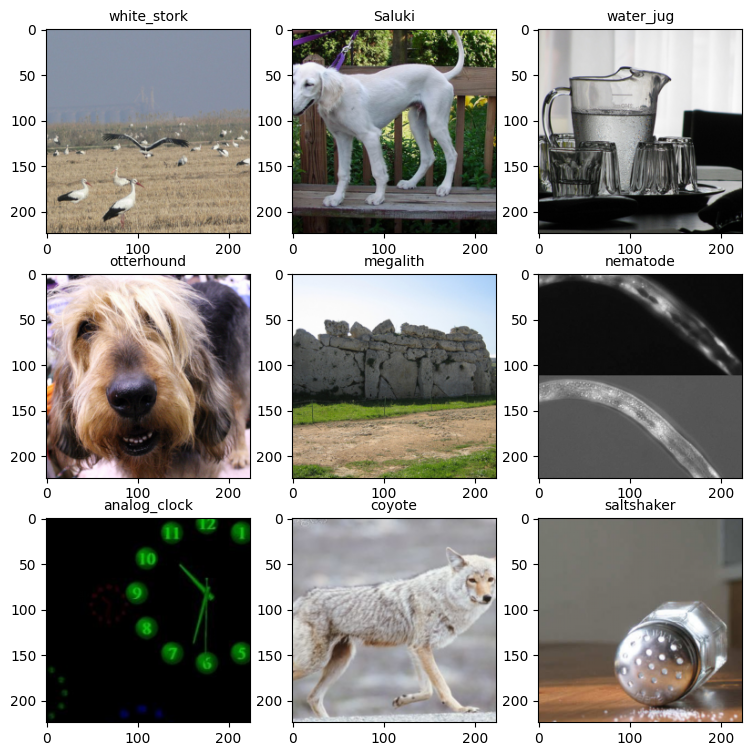

In [93]:
# Plot samples from train dataset
plot_samples(train_dataset_full, figname="Train samples visualization")

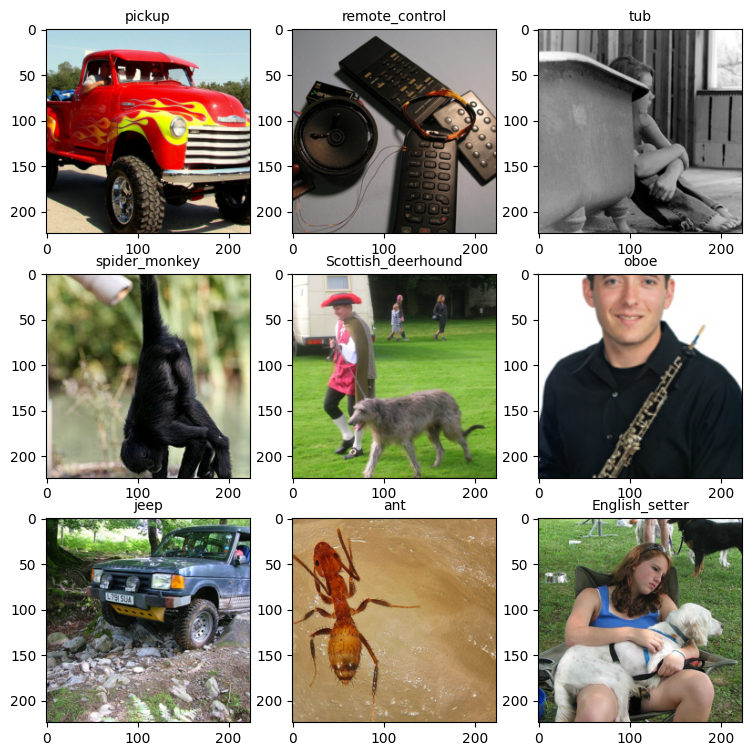

In [56]:
# Plot samples for test dataset
plot_samples(test_dataset_split, figname="Test samples visualization")

# Build AlexNet model from scratch


In [57]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device


2.12.0+cu126


'cuda'

## Custom Normalization

In [58]:
import torch
from torch import nn
import math

class ResponseNormalization(nn.Module):
    def __init__(self, k=2, n=5, alpha=1e-4, beta=0.75):
        super().__init__()
        self.k = k
        self.n = n
        self.alpha = alpha
        self.beta = beta
    
    def forward(self, x:torch.Tensor):
        '''
        x: A tensor of shape (N, C, H, W)
        '''
        tensor_shape = list(x.size())
        N = tensor_shape[0]
        z = torch.zeros(tensor_shape)
        for i in range(tensor_shape[1]):
            z[:, i, :, :] = x[:, i, :, :] / torch.pow((self.k + self.alpha * torch.sum(torch.pow(x[:, int(max(0, i - self.n/2)) : int(min(N-1, i+self.n/2)), :, :], 2), dim=1)), self.beta)            
        return z

In [59]:
# Test reponse normalize function
torch.manual_seed(42)
X = torch.rand([1, 10, 3, 3])
normalization = ResponseNormalization()
X_norm = normalization(X)
print('Randomized tensor: ', X[0, 0, :, :])
print('Normalized tensor: ', X_norm[0, 0, :, :])

Randomized tensor:  tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
Normalized tensor:  tensor([[0.5246, 0.5441, 0.2277],
        [0.5704, 0.2322, 0.3573],
        [0.1526, 0.4719, 0.5594]])


$$O = \dfrac{I-K+2P}{S} + 1$$

## AlexNet

In [60]:
        
class AlexNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Layer 1: start from 224 x 224
        self.layer1A = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=48, kernel_size=11, stride=4, padding=2), # 55 x 55 
            nn.ReLU(),
            ResponseNormalization(),
            nn.MaxPool2d(kernel_size=3, stride=2) # 27 x 27
        )

        self.layer1B = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=48, kernel_size=11, stride=4, padding=2), # 55 x 55
            nn.ReLU(),
            ResponseNormalization(),
            nn.MaxPool2d(kernel_size=3, stride=2) # 27 x 27
        )

        # Layer 2: start from 27 x 27
        self.layer2A = nn.Sequential(
            nn.Conv2d(in_channels=48, out_channels=128, kernel_size=5, stride=1, padding=2), # 27 x 27
            nn.ReLU(),
            ResponseNormalization(),
            nn.MaxPool2d(kernel_size=3, stride=2) # 13 x 13
        )

        self.layer2B = nn.Sequential(
            nn.Conv2d(in_channels=48, out_channels=128, kernel_size=5, stride=1, padding=2), # 27 x 27
            nn.ReLU(),
            ResponseNormalization(),
            nn.MaxPool2d(kernel_size=3, stride=2) # 13 x 13
        )

        # Layer 3, 4, 5: start from 13 x 13
        self.layer3A = nn.Sequential(
            nn.Conv2d(in_channels=128*2, out_channels=192, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU()
        )

        self.layer3B = nn.Sequential(
            nn.Conv2d(in_channels=128*2, out_channels=192, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU()
        )
        
        self.layer4A = nn.Sequential(
            nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU()
        )

        self.layer4B = nn.Sequential(
            nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU()
        )

        self.layer5A = nn.Sequential(
            nn.Conv2d(in_channels=192, out_channels=128, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2) # 6 x 6
        )

        self.layer5B = nn.Sequential(
            nn.Conv2d(in_channels=192, out_channels=128, kernel_size=3, padding=1), # 13 x 13
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2) # 6 x 6
        )

        # Layer 6, 7, 8: start from 128 x 2 x 6 x 6
        self.dense_layer = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=128*2*6*6, out_features=4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(),
            nn.Linear(in_features=4096, out_features=1000)
        )

    def forward(self, x):
        # Feedforward from layer 1 to layer 2
        a = self.layer2A(self.layer1A(x))
        b = self.layer2B(self.layer1B(x))

        # Merge two results
        c = torch.concatenate((a, b), dim=1)

        # Feedforward from layer 3 to layer 5 
        a = self.layer5A(self.layer4A(self.layer3A(c)))
        b = self.layer5B(self.layer4B(self.layer3B(c)))

        # Merge two results
        c = torch.concatenate((a, b), dim=1)

        # Feedforward dense layer
        z = self.dense_layer(c)
        return z



In [61]:
model = AlexNet()
model

AlexNet(
  (layer1A): Sequential(
    (0): Conv2d(3, 48, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU()
    (2): ResponseNormalization()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer1B): Sequential(
    (0): Conv2d(3, 48, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU()
    (2): ResponseNormalization()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2A): Sequential(
    (0): Conv2d(48, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): ResponseNormalization()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2B): Sequential(
    (0): Conv2d(48, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): ResponseNormalization()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3A): Sequential(
    (0): Conv2

## Prepare Loss function and Optimizer


In [62]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [68]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn, device="cpu"):
    model.train()
    model.to(device)
    train_loss = 0
    train_acc = 0
    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true = y, y_pred=y_pred.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if (batch % 200 == 0):
            print(f"Training batch {batch} / {len(dataloader)}")
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    print(f"Train loss: {train_loss} | Train acc: {train_acc}")
    
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer, accuracy_fn, device="cpu"):
    model.to(device)
    model.eval()
    test_loss = 0
    test_acc = 0
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device)
            y = y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y, test_pred.argmax(dim=1))
            if (batch % 200 == 0):
                print(f"Testing batch {batch} / {len(dataloader)}")
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
    print(f"Test loss: {test_loss} | Test acc: {test_acc}")
    

In [69]:
# Training loop
epochs = 20
print(device)
for epoch in range(epochs): 
    print(f"Epoch [{epoch}/{epochs}]=========")
    train_step(
        model=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(
        model=model,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )



cuda
Epoch [0/20]=========


RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor